In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

manifest_path = Path("data/data/er_benchmark_v2_500/manifest.csv")
manifest = pd.read_csv(manifest_path)
data_dir = manifest_path.parent

In [3]:
row = manifest[
    (manifest["n"] == 30) &
    (np.isclose(manifest["p"], 0.15)) &
    (np.isclose(manifest["noise"], 0.0)) &
    (manifest["seed_id"] == 0)
].iloc[0]

data = np.load(data_dir / row["filename"], allow_pickle=True)

A = data["A"]
B = data["B"]
pi_true = data["pi_true"]

print("Loaded:", row["filename"])
print("True score:", row["true_score"])

Loaded: er_n30_p015_eps000_seed000_resample.npz
True score: 70.0


In [4]:
def edge_overlap_score(A, B, pi):
    n = A.shape[0]
    score = 0
    for i in range(n):
        for j in range(i + 1, n):
            score += A[i, j] * B[pi[i], pi[j]]
    return score


def alignment_accuracy(pi_hat, pi_true):
    return np.mean(pi_hat == pi_true)


def propose_swap(pi, rng):
    pi_new = pi.copy()
    n = len(pi)
    i, j = rng.choice(n, size=2, replace=False)
    pi_new[i], pi_new[j] = pi_new[j], pi_new[i]
    return pi_new


def simulated_annealing(A, B, pi_true=None, num_iters=5000,
                        beta_start=0.01, beta_end=5.0,
                        seed=None):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    pi = rng.permutation(n)
    current_score = edge_overlap_score(A, B, pi)

    best_pi = pi.copy()
    best_score = current_score

    for t in range(num_iters):
        beta = beta_start + (beta_end - beta_start) * t / (num_iters - 1)

        pi_new = propose_swap(pi, rng)
        new_score = edge_overlap_score(A, B, pi_new)

        delta = new_score - current_score

        if delta >= 0:
            accept = True
        else:
            accept = rng.random() < np.exp(beta * delta)

        if accept:
            pi = pi_new
            current_score = new_score

        if current_score > best_score:
            best_pi = pi.copy()
            best_score = current_score

    return best_pi, float(best_score)

In [5]:
def collect_restart_solutions(
    A, B, pi_true,
    num_restarts=50,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    seed=0
):
    rng = np.random.default_rng(seed)
    solutions = []

    for r in range(num_restarts):
        run_seed = int(rng.integers(1_000_000_000))

        best_pi, best_score = simulated_annealing(
            A, B,
            pi_true=pi_true,
            num_iters=num_iters,
            beta_start=beta_start,
            beta_end=beta_end,
            seed=run_seed
        )

        solutions.append({
            "restart": r,
            "pi": best_pi,
            "score": best_score,
            "accuracy": float(alignment_accuracy(best_pi, pi_true))
        })

        print(
            f"restart {r:02d}: "
            f"score={best_score:.1f}, "
            f"accuracy={alignment_accuracy(best_pi, pi_true):.3f}"
        )

    return solutions

In [6]:
solutions = collect_restart_solutions(
    A, B, pi_true,
    num_restarts=50,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    seed=999
)

restart 00: score=41.0, accuracy=0.000
restart 01: score=44.0, accuracy=0.033
restart 02: score=43.0, accuracy=0.033
restart 03: score=48.0, accuracy=0.433
restart 04: score=70.0, accuracy=1.000
restart 05: score=43.0, accuracy=0.033
restart 06: score=70.0, accuracy=1.000
restart 07: score=44.0, accuracy=0.200
restart 08: score=70.0, accuracy=1.000
restart 09: score=41.0, accuracy=0.033
restart 10: score=42.0, accuracy=0.133
restart 11: score=40.0, accuracy=0.033
restart 12: score=45.0, accuracy=0.067
restart 13: score=43.0, accuracy=0.067
restart 14: score=43.0, accuracy=0.033
restart 15: score=50.0, accuracy=0.567
restart 16: score=43.0, accuracy=0.067
restart 17: score=70.0, accuracy=1.000
restart 18: score=42.0, accuracy=0.200
restart 19: score=50.0, accuracy=0.467
restart 20: score=70.0, accuracy=1.000
restart 21: score=42.0, accuracy=0.067
restart 22: score=43.0, accuracy=0.033
restart 23: score=42.0, accuracy=0.067
restart 24: score=43.0, accuracy=0.033
restart 25: score=42.0, a

In [7]:
def permutation_distance(pi1, pi2):
    return 1.0 - np.mean(pi1 == pi2)


def cluster_solutions_by_distance(solutions, distance_threshold=0.2):
    sorted_solutions = sorted(
        solutions,
        key=lambda x: x["score"],
        reverse=True
    )

    modes = []

    for sol in sorted_solutions:
        assigned = False

        for mode in modes:
            dist = permutation_distance(sol["pi"], mode["representative_pi"])

            if dist <= distance_threshold:
                mode["members"].append(sol)
                assigned = True
                break

        if not assigned:
            modes.append({
                "representative_pi": sol["pi"],
                "representative_score": sol["score"],
                "representative_accuracy": sol["accuracy"],
                "members": [sol]
            })

    return modes

In [8]:
modes = cluster_solutions_by_distance(solutions, distance_threshold=0.2)

print("Approximate number of modes found:", len(modes))

for k, mode in enumerate(modes):
    scores = [m["score"] for m in mode["members"]]
    accs = [m["accuracy"] for m in mode["members"]]

    print(
        f"Mode {k}: "
        f"size={len(mode['members'])}, "
        f"best_score={max(scores):.1f}, "
        f"mean_score={np.mean(scores):.1f}, "
        f"best_acc={max(accs):.3f}, "
        f"mean_acc={np.mean(accs):.3f}"
    )

Approximate number of modes found: 44
Mode 0: size=7, best_score=70.0, mean_score=70.0, best_acc=1.000, mean_acc=1.000
Mode 1: size=1, best_score=50.0, mean_score=50.0, best_acc=0.567, mean_acc=0.567
Mode 2: size=1, best_score=50.0, mean_score=50.0, best_acc=0.467, mean_acc=0.467
Mode 3: size=1, best_score=48.0, mean_score=48.0, best_acc=0.433, mean_acc=0.433
Mode 4: size=1, best_score=47.0, mean_score=47.0, best_acc=0.367, mean_acc=0.367
Mode 5: size=1, best_score=45.0, mean_score=45.0, best_acc=0.067, mean_acc=0.067
Mode 6: size=1, best_score=45.0, mean_score=45.0, best_acc=0.333, mean_acc=0.333
Mode 7: size=1, best_score=45.0, mean_score=45.0, best_acc=0.000, mean_acc=0.000
Mode 8: size=1, best_score=45.0, mean_score=45.0, best_acc=0.233, mean_acc=0.233
Mode 9: size=1, best_score=44.0, mean_score=44.0, best_acc=0.033, mean_acc=0.033
Mode 10: size=1, best_score=44.0, mean_score=44.0, best_acc=0.200, mean_acc=0.200
Mode 11: size=1, best_score=44.0, mean_score=44.0, best_acc=0.300, mea

In [9]:
best_score_seen = max(sol["score"] for sol in solutions)

high_score_solutions = [
    sol for sol in solutions
    if sol["score"] >= best_score_seen - 5
]

modes_high = cluster_solutions_by_distance(
    high_score_solutions,
    distance_threshold=0.2
)

print("Best score seen:", best_score_seen)
print("Number of high-scoring solutions:", len(high_score_solutions))
print("Approximate number of high-scoring modes:", len(modes_high))

for k, mode in enumerate(modes_high):
    scores = [m["score"] for m in mode["members"]]
    accs = [m["accuracy"] for m in mode["members"]]

    print(
        f"High-score mode {k}: "
        f"size={len(mode['members'])}, "
        f"best_score={max(scores):.1f}, "
        f"mean_score={np.mean(scores):.1f}, "
        f"best_acc={max(accs):.3f}, "
        f"mean_acc={np.mean(accs):.3f}"
    )

Best score seen: 70.0
Number of high-scoring solutions: 7
Approximate number of high-scoring modes: 1
High-score mode 0: size=7, best_score=70.0, mean_score=70.0, best_acc=1.000, mean_acc=1.000


In [11]:
row_noisy = manifest[
    (manifest["n"] == 30) &
    (np.isclose(manifest["p"], 0.15)) &
    (np.isclose(manifest["noise"], 0.2)) &
    (manifest["seed_id"] == 0)
].iloc[0]

data_noisy = np.load(data_dir / row_noisy["filename"], allow_pickle=True)

A_noisy = data_noisy["A"]
B_noisy = data_noisy["B"]
pi_true_noisy = data_noisy["pi_true"]

print("Loaded:", row_noisy["filename"])
print("True score:", row_noisy["true_score"])
print("True score from function:", edge_overlap_score(A_noisy, B_noisy, pi_true_noisy))

Loaded: er_n30_p015_eps020_seed000_resample.npz
True score: 56.0
True score from function: 56


In [12]:
solutions_noisy = collect_restart_solutions(
    A_noisy,
    B_noisy,
    pi_true_noisy,
    num_restarts=50,
    num_iters=10000,
    beta_start=0.01,
    beta_end=5.0,
    seed=1001
)

restart 00: score=45.0, accuracy=0.267
restart 01: score=46.0, accuracy=0.300
restart 02: score=40.0, accuracy=0.033
restart 03: score=41.0, accuracy=0.067
restart 04: score=41.0, accuracy=0.100
restart 05: score=42.0, accuracy=0.133
restart 06: score=41.0, accuracy=0.033
restart 07: score=40.0, accuracy=0.033
restart 08: score=40.0, accuracy=0.000
restart 09: score=43.0, accuracy=0.100
restart 10: score=51.0, accuracy=0.500
restart 11: score=41.0, accuracy=0.100
restart 12: score=43.0, accuracy=0.200
restart 13: score=41.0, accuracy=0.000
restart 14: score=39.0, accuracy=0.033
restart 15: score=43.0, accuracy=0.100
restart 16: score=40.0, accuracy=0.000
restart 17: score=39.0, accuracy=0.033
restart 18: score=47.0, accuracy=0.267
restart 19: score=41.0, accuracy=0.133
restart 20: score=56.0, accuracy=1.000
restart 21: score=43.0, accuracy=0.133
restart 22: score=46.0, accuracy=0.267
restart 23: score=45.0, accuracy=0.500
restart 24: score=38.0, accuracy=0.167
restart 25: score=41.0, a

In [13]:
modes_noisy = cluster_solutions_by_distance(
    solutions_noisy,
    distance_threshold=0.2
)

print("Approximate number of modes found:", len(modes_noisy))

for k, mode in enumerate(modes_noisy):
    scores = [m["score"] for m in mode["members"]]
    accs = [m["accuracy"] for m in mode["members"]]

    print(
        f"Mode {k}: "
        f"size={len(mode['members'])}, "
        f"best_score={max(scores):.1f}, "
        f"mean_score={np.mean(scores):.1f}, "
        f"best_acc={max(accs):.3f}, "
        f"mean_acc={np.mean(accs):.3f}"
    )

Approximate number of modes found: 50
Mode 0: size=1, best_score=56.0, mean_score=56.0, best_acc=1.000, mean_acc=1.000
Mode 1: size=1, best_score=51.0, mean_score=51.0, best_acc=0.500, mean_acc=0.500
Mode 2: size=1, best_score=50.0, mean_score=50.0, best_acc=0.500, mean_acc=0.500
Mode 3: size=1, best_score=48.0, mean_score=48.0, best_acc=0.500, mean_acc=0.500
Mode 4: size=1, best_score=48.0, mean_score=48.0, best_acc=0.367, mean_acc=0.367
Mode 5: size=1, best_score=47.0, mean_score=47.0, best_acc=0.267, mean_acc=0.267
Mode 6: size=1, best_score=46.0, mean_score=46.0, best_acc=0.300, mean_acc=0.300
Mode 7: size=1, best_score=46.0, mean_score=46.0, best_acc=0.267, mean_acc=0.267
Mode 8: size=1, best_score=46.0, mean_score=46.0, best_acc=0.233, mean_acc=0.233
Mode 9: size=1, best_score=45.0, mean_score=45.0, best_acc=0.267, mean_acc=0.267
Mode 10: size=1, best_score=45.0, mean_score=45.0, best_acc=0.500, mean_acc=0.500
Mode 11: size=1, best_score=44.0, mean_score=44.0, best_acc=0.233, mea

In [14]:
best_score_seen_noisy = max(sol["score"] for sol in solutions_noisy)

for cutoff in [3, 5, 10]:
    high_score_solutions_noisy = [
        sol for sol in solutions_noisy
        if sol["score"] >= best_score_seen_noisy - cutoff
    ]

    modes_high_noisy = cluster_solutions_by_distance(
        high_score_solutions_noisy,
        distance_threshold=0.2
    )

    print("\nScore cutoff: within", cutoff, "of best score")
    print("Best score seen:", best_score_seen_noisy)
    print("Number of high-scoring solutions:", len(high_score_solutions_noisy))
    print("Approximate number of high-scoring modes:", len(modes_high_noisy))

    for k, mode in enumerate(modes_high_noisy):
        scores = [m["score"] for m in mode["members"]]
        accs = [m["accuracy"] for m in mode["members"]]

        print(
            f"High-score mode {k}: "
            f"size={len(mode['members'])}, "
            f"best_score={max(scores):.1f}, "
            f"mean_score={np.mean(scores):.1f}, "
            f"best_acc={max(accs):.3f}, "
            f"mean_acc={np.mean(accs):.3f}"
        )


Score cutoff: within 3 of best score
Best score seen: 56.0
Number of high-scoring solutions: 1
Approximate number of high-scoring modes: 1
High-score mode 0: size=1, best_score=56.0, mean_score=56.0, best_acc=1.000, mean_acc=1.000

Score cutoff: within 5 of best score
Best score seen: 56.0
Number of high-scoring solutions: 2
Approximate number of high-scoring modes: 2
High-score mode 0: size=1, best_score=56.0, mean_score=56.0, best_acc=1.000, mean_acc=1.000
High-score mode 1: size=1, best_score=51.0, mean_score=51.0, best_acc=0.500, mean_acc=0.500

Score cutoff: within 10 of best score
Best score seen: 56.0
Number of high-scoring solutions: 9
Approximate number of high-scoring modes: 9
High-score mode 0: size=1, best_score=56.0, mean_score=56.0, best_acc=1.000, mean_acc=1.000
High-score mode 1: size=1, best_score=51.0, mean_score=51.0, best_acc=0.500, mean_acc=0.500
High-score mode 2: size=1, best_score=50.0, mean_score=50.0, best_acc=0.500, mean_acc=0.500
High-score mode 3: size=1, 

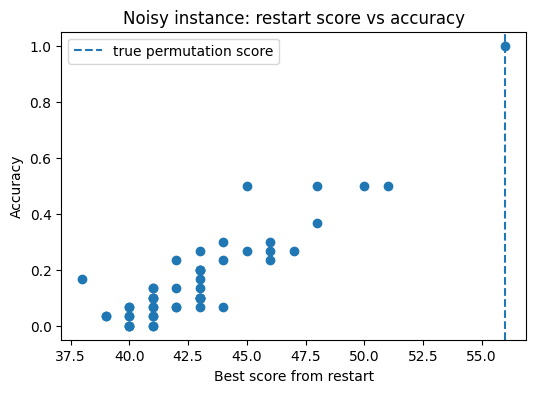

In [15]:
scores_noisy = [sol["score"] for sol in solutions_noisy]
accs_noisy = [sol["accuracy"] for sol in solutions_noisy]

plt.figure(figsize=(6, 4))
plt.scatter(scores_noisy, accs_noisy)
plt.axvline(row_noisy["true_score"], linestyle="--", label="true permutation score")
plt.xlabel("Best score from restart")
plt.ylabel("Accuracy")
plt.title("Noisy instance: restart score vs accuracy")
plt.legend()
plt.show()

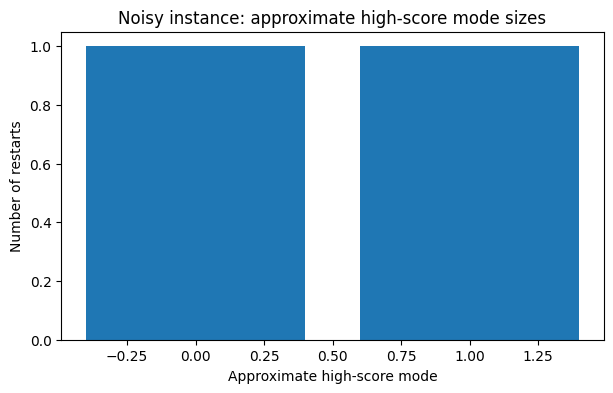

In [16]:
high_score_solutions_noisy = [
    sol for sol in solutions_noisy
    if sol["score"] >= best_score_seen_noisy - 5
]

modes_high_noisy = cluster_solutions_by_distance(
    high_score_solutions_noisy,
    distance_threshold=0.2
)

mode_sizes_noisy = [len(mode["members"]) for mode in modes_high_noisy]

plt.figure(figsize=(7, 4))
plt.bar(range(len(mode_sizes_noisy)), mode_sizes_noisy)
plt.xlabel("Approximate high-score mode")
plt.ylabel("Number of restarts")
plt.title("Noisy instance: approximate high-score mode sizes")
plt.show()